# Model Demonstration
Trey Wenger, 2025

In [1]:
import numpy as np
rng = np.random.RandomState(seed=1234)

import matplotlib.pyplot as plt

samples = 100_000

Text(0.5, 0, '$\\log_{10} EM$ (pc cm$^{-6}$)')

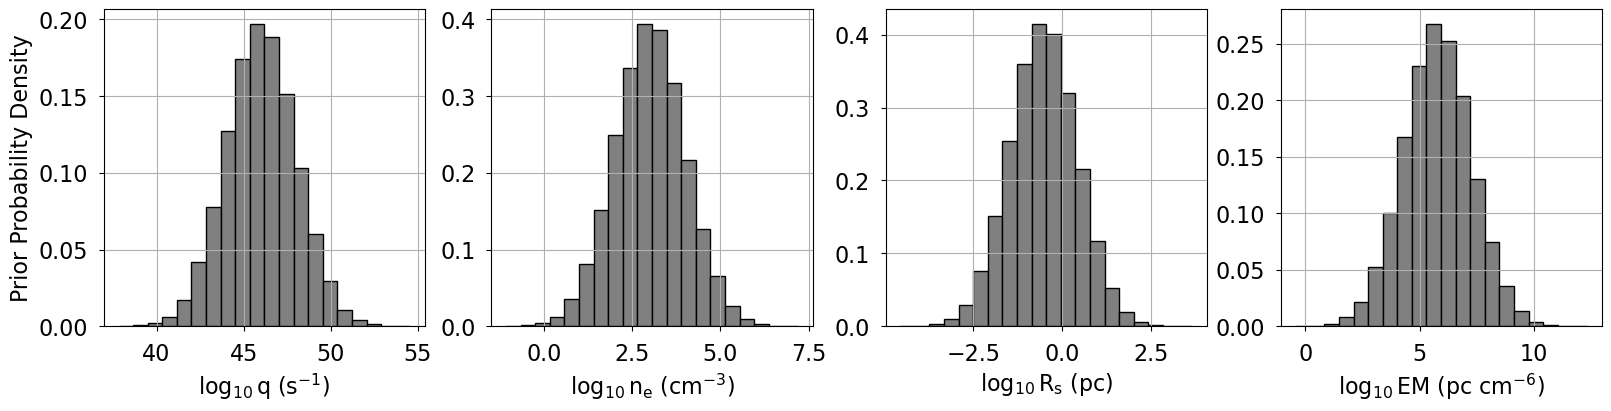

In [2]:
from scipy.stats import norm
#q_norm = halfnorm.rvs(loc=0.0, scale=1.0, size=samples)
log10_q_norm = norm.rvs(size=samples)
log10_q = 2.0*log10_q_norm + 46.0
#ne_norm = halfnorm.rvs(loc=0.0, scale=1.0, size=samples)
log10_ne_norm = norm.rvs(size=samples)
log10_ne = log10_ne_norm + 3.0
Rs = 1.4 * (10.0**log10_ne / 100.0)**(-2.0/3.0) * (10.0**log10_q / 1.0e46)**(1.0/3.0)
em = (10.0**log10_ne)**2.0 * 2.0 * Rs

fig, axes = plt.subplots(1, 4, figsize=(16, 4), layout="constrained")
axes[0].hist(log10_q, bins=20, density=True, color='gray', edgecolor='k')
axes[0].set_xlabel(r"$\log_{10} q$ (s$^{-1}$)")
axes[0].set_ylabel("Prior Probability Density")

axes[1].hist(log10_ne, bins=20, density=True, color='gray', edgecolor='k')
axes[1].set_xlabel(r"$\log_{10} n_e$ (cm$^{-3}$)")

axes[2].hist(np.log10(Rs), bins=20, density=True, color='gray', edgecolor='k')
axes[2].set_xlabel(r"$\log_{10} R_s$ (pc)")

axes[3].hist(np.log10(em), bins=20, density=True, color='gray', edgecolor='k')
axes[3].set_xlabel(r"$\log_{10} EM$ (pc cm$^{-6}$)")

Text(0.5, 0, '$\\log_{10} R_s$ (pc)')

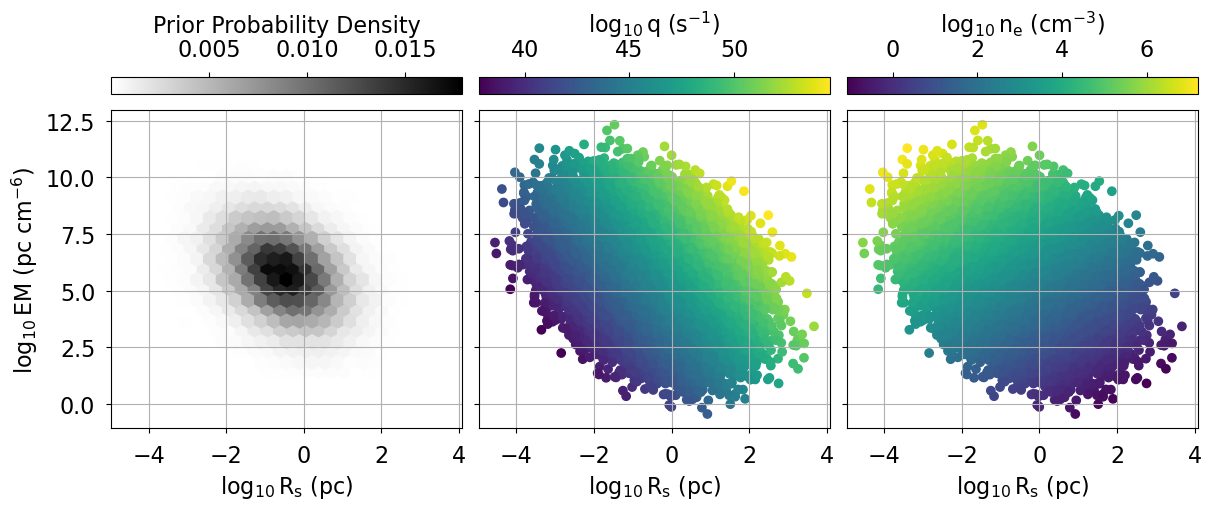

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), layout="constrained", sharex=True, sharey=True)
cax = axes[0].hexbin(
    np.log10(Rs),
    np.log10(em),
    C=np.ones_like(Rs)/samples,
    mincnt=1,
    #extent=[-2, 3, -1, 5],
    gridsize=25,
    cmap='binary',
    reduce_C_function=np.sum,
)
cbar = fig.colorbar(cax, label="Prior Probability Density", location='top')
axes[0].set_xlabel(r"$\log_{10} R_s$ (pc)")
axes[0].set_ylabel(r"$\log_{10} EM$ (pc cm$^{-6}$)")

cax = axes[1].scatter(
    np.log10(Rs),
    np.log10(em),
    c=log10_q,
)
cbar = fig.colorbar(cax, label=r"$\log_{10} q$ (s$^{-1}$)", location='top')
axes[1].set_xlabel(r"$\log_{10} R_s$ (pc)")

cax = axes[2].scatter(
    np.log10(Rs),
    np.log10(em),
    c=log10_ne,
)
cbar = fig.colorbar(cax, label=r"$\log_{10} n_e$ (cm$^{-3}$)", location='top')
axes[2].set_xlabel(r"$\log_{10} R_s$ (pc)")

Text(0.5, 0, '$\\log_{10} \\theta$ (arcsec)')

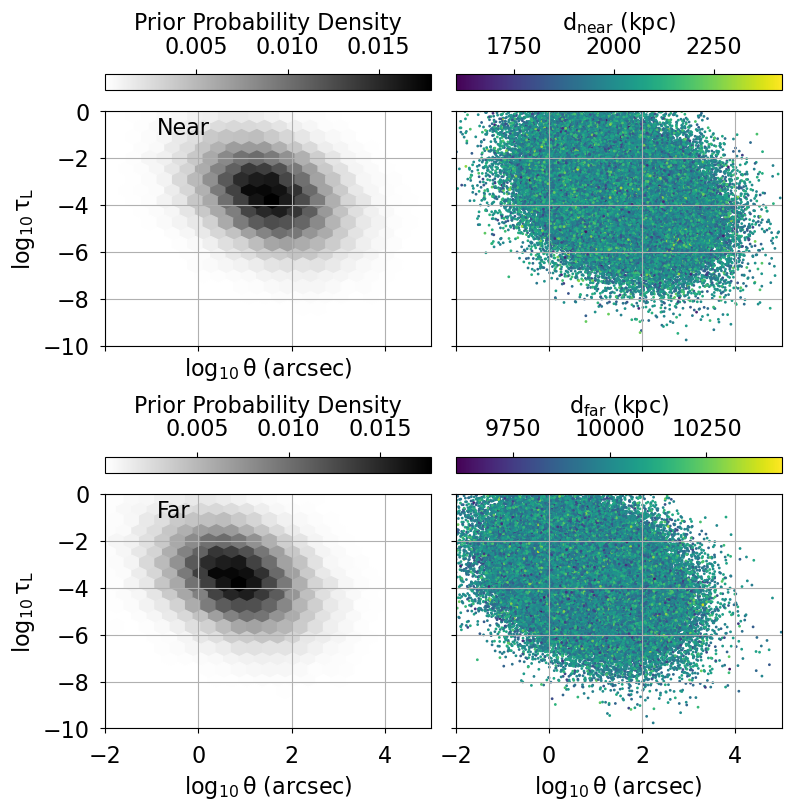

In [4]:
# data for G043.175+00.025 idx = 658
te = 8000.0 # K
fwhm_kHz = 700.0 # kHz
tau_line = 1.92e3 * te**-2.5 * em / fwhm_kHz

d_near = rng.normal(size=samples)*100.0 + 2000.0 # pc
d_far = rng.normal(size=samples)*100.0 + 10000.0 # pc
radius_near = Rs / d_near * 206265.0
radius_far = Rs / d_far * 206265.0

fig, axes = plt.subplots(2, 2, figsize=(8, 8), layout="constrained", sharex=True, sharey=True)
cax = axes[0, 0].hexbin(
    np.log10(radius_near),
    np.log10(tau_line),
    C=np.ones_like(radius_near)/samples,
    mincnt=1,
    gridsize=25,
    reduce_C_function=np.sum,
    cmap="binary",
)
cbar = fig.colorbar(cax, label="Prior Probability Density", location="top")
axes[0, 0].text(-0.9, -1.0, "Near")
axes[0, 0].set_xlabel(r"$\log_{10} \theta$ (arcsec)")
axes[0, 0].set_ylabel(r"$\log_{10} \tau_L$")
axes[0, 0].set_xlim(-2.0, 5.0)
axes[0, 0].set_ylim(-10.0, 0.0)

cax = axes[0, 1].scatter(
    np.log10(radius_near),
    np.log10(tau_line),
    c=d_near,
    s=1,
)
cbar = fig.colorbar(cax, label=r"$d_{\rm near}$ (kpc)", location="top")

cax = axes[1, 0].hexbin(
    np.log10(radius_far),
    np.log10(tau_line),
    C=np.ones_like(radius_far)/samples,
    mincnt=1,
    gridsize=25,
    reduce_C_function=np.sum,
    cmap="binary",
)
cbar = fig.colorbar(cax, label="Prior Probability Density", location="top")
axes[1, 0].text(-0.9, -1.0, "Far")
axes[1, 0].set_xlabel(r"$\log_{10} \theta$ (arcsec)")
axes[1, 0].set_ylabel(r"$\log_{10} \tau_L$")

cax = axes[1, 1].scatter(
    np.log10(radius_far),
    np.log10(tau_line),
    c=d_far,
    s=1,
)
cbar = fig.colorbar(cax, label=r"$d_{\rm far}$ (kpc)", location="top")
axes[1, 1].set_xlabel(r"$\log_{10} \theta$ (arcsec)")

In [5]:
extent = [-3.0, 7.0, -12.0, 2.0]
log10_theta_grid, log10_tau_line_grid = np.mgrid[extent[0]:extent[1]:0.01, extent[2]:extent[3]:0.01]
print(log10_theta_grid.shape)

(1000, 1400)


Text(0.5, 0, '$\\tau_L$')

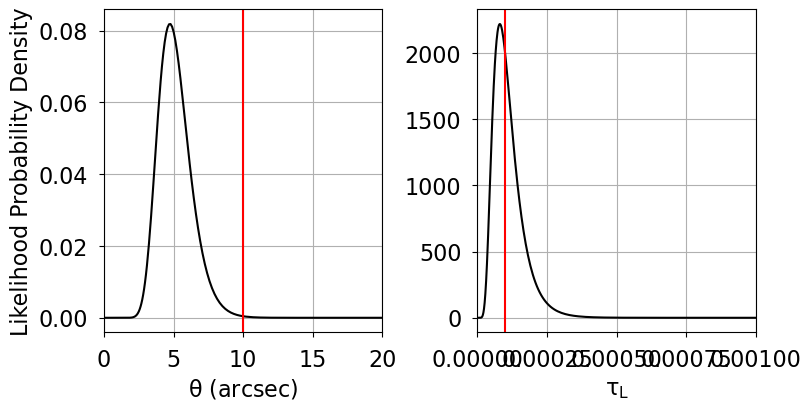

In [6]:
from scipy.special import logsumexp
from scipy.stats import truncnorm, norm, lognorm

theta_obs = 10.0 # arcsec
tau_line_obs = 1.0e-4

#loc = 2.0*10.0**log10_theta_grid
#scale = 0.25*theta_obs
#a = -loc/scale
#b = np.inf
#theta_lnlike = truncnorm(a=a, b=b, loc=loc, scale=scale).logpdf(theta_obs)
#log10_theta_lnlike = theta_lnlike + log10_theta_grid*np.log(10.0) + np.log(10.0)
log10_theta_lnlike = norm(loc=log10_theta_grid, scale=0.1).logpdf(np.log10(0.5*theta_obs))
theta_lnlike = log10_theta_lnlike - log10_theta_grid*np.log(10.0) - np.log(10.0)
log10_theta_lnlike_norm = log10_theta_lnlike - log10_theta_lnlike.max()

#log10_theta_lnlike = -(log10_theta_grid - np.log10(theta_obs/2.0))**2.0/(2.0 * 0.1**2.0)
#log10_theta_lnlike -= log10_theta_lnlike.max()
#theta_lnlike = log10_theta_lnlike - log10_theta_grid*np.log(10.0) - np.log(10.0)
#theta_lnlike -= theta_lnlike.max()

#loc = 10.0**log10_tau_line_grid
#scale = 0.25*tau_line_obs
#a = -loc/scale
#b = np.inf
#tau_line_lnlike = truncnorm(a=a, b=b, loc=loc, scale=scale).logpdf(tau_line_obs)
#log10_tau_line_lnlike = tau_line_lnlike + log10_tau_line_grid*np.log(10.0) + np.log(10.0)
log10_tau_line_lnlike = norm(loc=log10_tau_line_grid, scale=0.2).logpdf(np.log10(tau_line_obs))
tau_line_lnlike = log10_tau_line_lnlike - log10_tau_line_grid*np.log(10.0) - np.log(10.0)
log10_tau_line_lnlike_norm = log10_tau_line_lnlike - log10_tau_line_lnlike.max()

#log10_tau_line_lnlike = -(log10_tau_line_grid - np.log10(tau_line_obs))**2.0/(2.0 * 0.5**2.0)
#log10_tau_line_lnlike -= log10_tau_line_lnlike.max()
#tau_line_lnlike = log10_tau_line_lnlike - log10_tau_line_grid*np.log(10.0) - np.log(10.0)
#tau_line_lnlike -= tau_line_lnlike.max()

total_lnlike = log10_theta_lnlike + log10_tau_line_lnlike
total_lnlike -= logsumexp(total_lnlike)
total_lnlike_norm = total_lnlike - total_lnlike.max()

fig, axes = plt.subplots(1, 2, figsize=(8, 4), layout="constrained")
axes[0].plot(10.0**log10_theta_grid[:, 0], np.exp(theta_lnlike[:, 0]), 'k-')
axes[0].set_xlim(0.0, 2.0*theta_obs)
axes[0].axvline(theta_obs, color='r')
axes[0].set_xlabel(r"$\theta$ (arcsec)")
axes[0].set_ylabel("Likelihood Probability Density")

axes[1].plot(10.0**log10_tau_line_grid[0, :], np.exp(tau_line_lnlike[0, :]), 'k-')
axes[1].set_xlim(0.0, 10.0*tau_line_obs)
axes[1].axvline(tau_line_obs, color='r')
axes[1].set_xlabel(r"$\tau_L$")

(-5.0, -2.0)

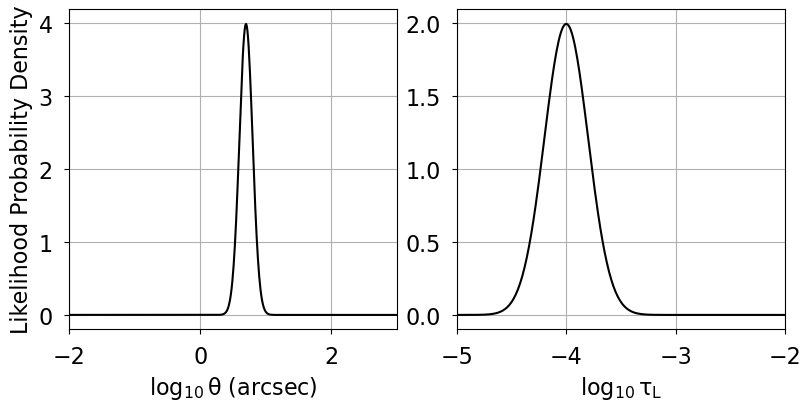

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), layout="constrained")
axes[0].plot(log10_theta_grid[:, 0], np.exp(log10_theta_lnlike[:, 0]), 'k-')
axes[0].set_xlabel(r"$\log_{10} \theta$ (arcsec)")
axes[0].set_ylabel("Likelihood Probability Density")
axes[0].set_xlim(-2, 3)

axes[1].plot(log10_tau_line_grid[0, :], np.exp(log10_tau_line_lnlike[0, :]), 'k-')
axes[1].set_xlabel(r"$\log_{10} \tau_L$")
axes[1].set_xlim(-5, -2)

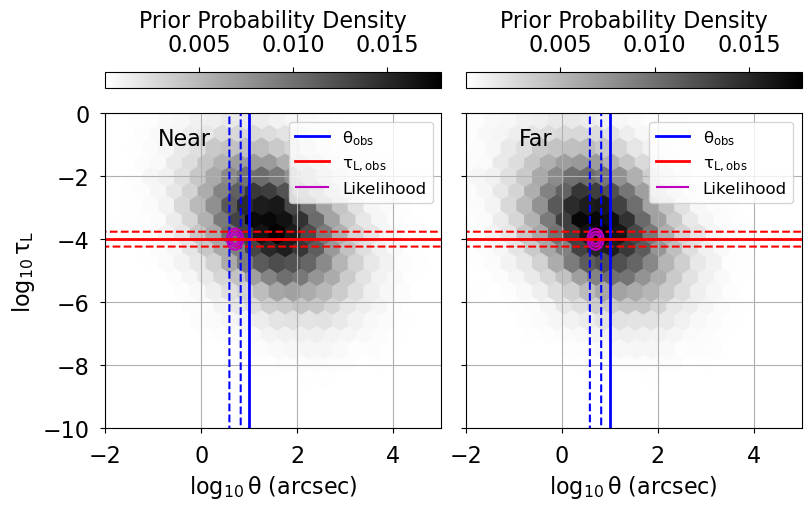

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5), layout="constrained", sharex=True, sharey=True)
cax = axes[0].hexbin(
    np.log10(radius_near),
    np.log10(tau_line),
    C=np.ones_like(radius_near)/samples,
    mincnt=1,
    gridsize=25,
    reduce_C_function=np.sum,
    cmap="binary",
)
cbar = fig.colorbar(cax, label="Prior Probability Density", location="top")
axes[0].text(-0.9, -1.0, "Near")
axes[0].set_xlim(-2.0, 5.0)
axes[0].set_ylim(-10.0, 0.0)

axes[0].set_xlabel(r"$\log_{10} \theta$ (arcsec)")
axes[0].set_ylabel(r"$\log_{10} \tau_L$")

axes[0].contour(np.exp(log10_theta_lnlike_norm).T, colors=['b'], levels=[0.5], linestyles='--', extent=extent)
axes[0].contour(np.exp(log10_tau_line_lnlike_norm).T, colors=['r'], levels=[0.5], linestyles='--', extent=extent)
cnt = axes[0].contour(np.exp(total_lnlike_norm).T, colors=['m'], levels=[0.25, 0.5, 0.75], linestyles='-', extent=extent)
cnt_handles, _ = cnt.legend_elements()
axes[0].axvline(np.log10(theta_obs), color='b', lw=2, label=r"$\theta_{\rm obs}$")
axes[0].axhline(np.log10(tau_line_obs), color='r', lw=2, label=r"$\tau_{L, \rm obs}$")
axes[0].legend(loc='best')
handles, labels = axes[0].get_legend_handles_labels()
handles += [cnt_handles[0]]
labels += ["Likelihood"]
axes[0].legend(handles, labels, loc='best', fontsize=12)

cax = axes[1].hexbin(
    np.log10(radius_far),
    np.log10(tau_line),
    C=np.ones_like(radius_far)/samples,
    mincnt=1,
    gridsize=25,
    reduce_C_function=np.sum,
    cmap="binary",
)
cbar = fig.colorbar(cax, label="Prior Probability Density", location="top")
axes[1].text(-0.9, -1.0, "Far")
axes[1].set_xlabel(r"$\log_{10} \theta$ (arcsec)")

axes[1].contour(np.exp(log10_theta_lnlike_norm).T, colors=['b'], levels=[0.5], linestyles='--', extent=extent)
axes[1].contour(np.exp(log10_tau_line_lnlike_norm).T, colors=['r'], levels=[0.5], linestyles='--', extent=extent)
cnt = axes[1].contour(np.exp(total_lnlike_norm).T, colors=['m'], levels=[0.25, 0.5, 0.75], linestyles='-', extent=extent)
axes[1].axvline(np.log10(theta_obs), color='b', lw=2, label=r"$\theta_{\rm obs}$")
axes[1].axhline(np.log10(tau_line_obs), color='r', lw=2, label=r"$\tau_{L, \rm obs}$")
axes[1].legend(loc='best')
handles, labels = axes[0].get_legend_handles_labels()
handles += [cnt_handles[0]]
labels += ["Likelihood"]
axes[1].legend(handles, labels, loc='best', fontsize=12)

In [9]:
lnlike_near = np.zeros_like(em)
lnlike_far = np.zeros_like(em)
for i in range(len(em)):
    idx_theta_near = np.argmin(np.abs(10.0**log10_theta_grid[:, 0] - radius_near[i]))
    idx_theta_far = np.argmin(np.abs(10.0**log10_theta_grid[:, 0] - radius_far[i]))
    idx_tau_line = np.argmin(np.abs(10.0**log10_tau_line_grid[0, :] - tau_line[i]))
    
    lnlike_near[i] = total_lnlike[idx_theta_near, idx_tau_line]
    lnlike_far[i] = total_lnlike[idx_theta_far, idx_tau_line]

Text(0.5, 0, '$\\log_{10} \\theta$ (arcsec)')

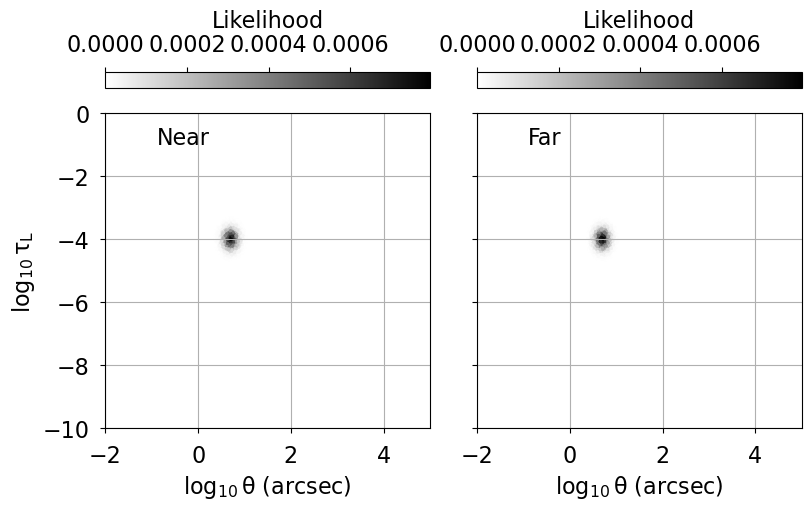

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5), layout="constrained", sharex=True, sharey=True)
cax = axes[0].scatter(
    np.log10(radius_near),
    np.log10(tau_line),
    c=np.exp(lnlike_near),
    cmap="binary",
    s=2,
)
cbar = fig.colorbar(cax, label="Likelihood", location="top")
axes[0].text(-0.9, -1.0, "Near")
axes[0].set_xlabel(r"$\log_{10} \theta$ (arcsec)")
axes[0].set_ylabel(r"$\log_{10} \tau_L$")
axes[0].set_xlim(-2.0, 5.0)
axes[0].set_ylim(-10.0, 0.0)

cax = axes[1].scatter(
    np.log10(radius_far),
    np.log10(tau_line),
    c=np.exp(lnlike_far),
    cmap="binary",
    s=2,
)
cbar = fig.colorbar(cax, label="Likelihood", location="top")
axes[1].text(-0.9, -1.0, "Far")
axes[1].set_xlabel(r"$\log_{10} \theta$ (arcsec)")

In [11]:
total_prob = np.exp(lnlike_near).sum() + np.exp(lnlike_far).sum()
posterior_near = np.exp(lnlike_near).sum()/total_prob
posterior_far = np.exp(lnlike_far).sum()/total_prob
print("near", posterior_near)
print("far", posterior_far)

near 0.3841740977474024
far 0.6158259022525976


Text(0.5, 0, '$\\log_{10} EM$ (pc cm$^{-6}$)')

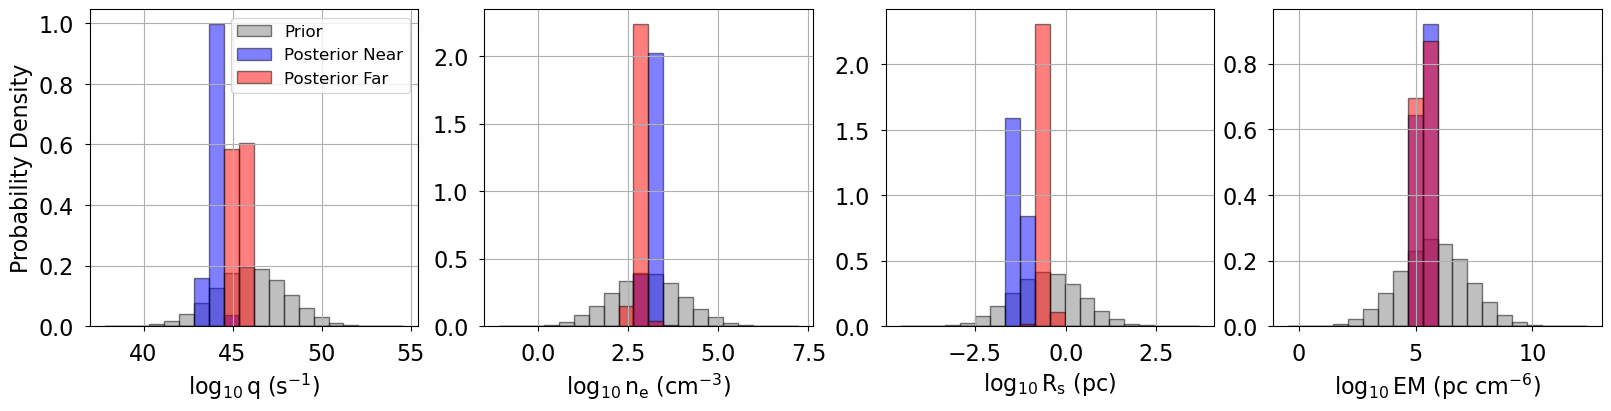

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), layout="constrained")
axes[0].hist(log10_q, bins=20, density=True, color='gray', edgecolor='k', label='Prior', alpha=0.5)
axes[0].hist(log10_q, weights=np.exp(lnlike_near), bins=20, density=True, color='blue', edgecolor='k', label='Posterior Near', alpha=0.5)
axes[0].hist(log10_q, weights=np.exp(lnlike_far), bins=20, density=True, color='red', edgecolor='k', label='Posterior Far', alpha=0.5)
axes[0].set_xlabel(r"$\log_{10} q$ (s$^{-1}$)")
axes[0].set_ylabel("Probability Density")
axes[0].legend(loc='best', fontsize=12)

axes[1].hist(log10_ne, bins=20, density=True, color='gray', edgecolor='k', alpha=0.5)
axes[1].hist(log10_ne, weights=np.exp(lnlike_near), bins=20, density=True, color='blue', edgecolor='k', alpha=0.5)
axes[1].hist(log10_ne, weights=np.exp(lnlike_far), bins=20, density=True, color='red', edgecolor='k', alpha=0.5)
axes[1].set_xlabel(r"$\log_{10} n_e$ (cm$^{-3}$)")

axes[2].hist(np.log10(Rs), bins=20, density=True, color='gray', edgecolor='k', alpha=0.5)
axes[2].hist(np.log10(Rs), weights=np.exp(lnlike_near), bins=20, density=True, color='blue', edgecolor='k', alpha=0.5)
axes[2].hist(np.log10(Rs), weights=np.exp(lnlike_far), bins=20, density=True, color='red', edgecolor='k', alpha=0.5)
axes[2].set_xlabel(r"$\log_{10} R_s$ (pc)")

axes[3].hist(np.log10(em), bins=20, density=True, color='gray', edgecolor='k', alpha=0.5)
axes[3].hist(np.log10(em), weights=np.exp(lnlike_near), bins=20, density=True, color='blue', edgecolor='k', alpha=0.5)
axes[3].hist(np.log10(em), weights=np.exp(lnlike_far), bins=20, density=True, color='red', edgecolor='k', alpha=0.5)
axes[3].set_xlabel(r"$\log_{10} EM$ (pc cm$^{-6}$)")

Text(0.5, 0, '$\\log_{10} EM$ (pc cm$^{-6}$)')

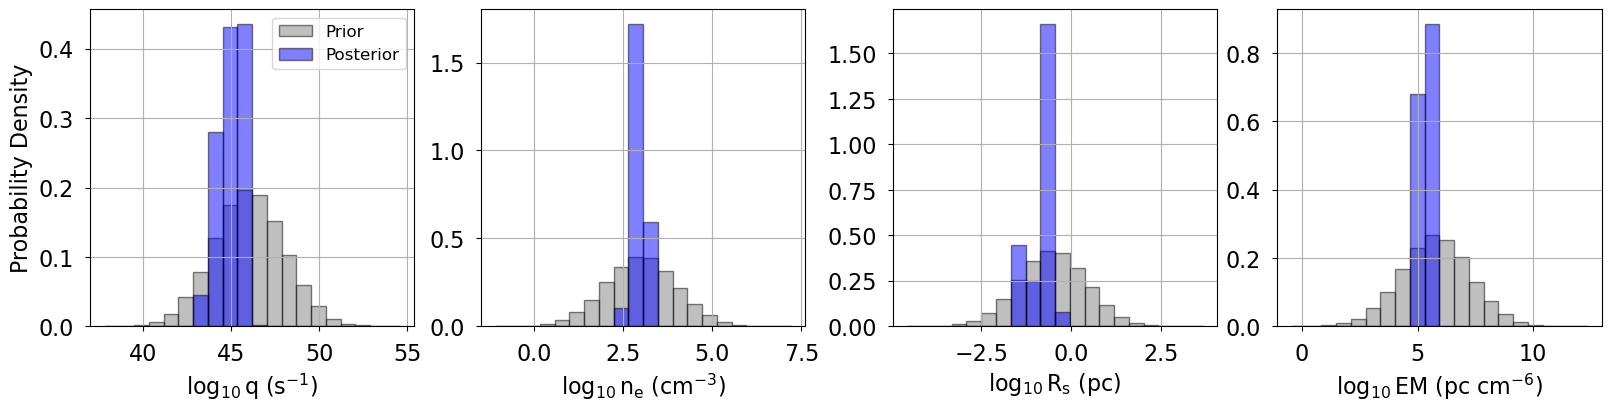

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), layout="constrained")
axes[0].hist(log10_q, bins=20, density=True, color='gray', edgecolor='k', label='Prior', alpha=0.5)
axes[0].hist(log10_q, weights=posterior_near * np.exp(lnlike_near) + posterior_far * np.exp(lnlike_far), bins=20, density=True, color='blue', edgecolor='k', label='Posterior', alpha=0.5)
axes[0].set_xlabel(r"$\log_{10} q$ (s$^{-1}$)")
axes[0].set_ylabel("Probability Density")
axes[0].legend(loc='best', fontsize=12)

axes[1].hist(log10_ne, bins=20, density=True, color='gray', edgecolor='k', alpha=0.5)
axes[1].hist(log10_ne, weights=posterior_near * np.exp(lnlike_near) + posterior_far * np.exp(lnlike_far), bins=20, density=True, color='blue', edgecolor='k', alpha=0.5)
axes[1].set_xlabel(r"$\log_{10} n_e$ (cm$^{-3}$)")

axes[2].hist(np.log10(Rs), bins=20, density=True, color='gray', edgecolor='k', alpha=0.5)
axes[2].hist(np.log10(Rs), weights=posterior_near * np.exp(lnlike_near) + posterior_far * np.exp(lnlike_far), bins=20, density=True, color='blue', edgecolor='k', alpha=0.5)
axes[2].set_xlabel(r"$\log_{10} R_s$ (pc)")

axes[3].hist(np.log10(em), bins=20, density=True, color='gray', edgecolor='k', alpha=0.5)
axes[3].hist(np.log10(em), weights=posterior_near * np.exp(lnlike_near) + posterior_far * np.exp(lnlike_far), bins=20, density=True, color='blue', edgecolor='k', alpha=0.5)
axes[3].set_xlabel(r"$\log_{10} EM$ (pc cm$^{-6}$)")